# SPR-04 — Figure Generation (scikit-plot)

**Ticket:** SPR-04
**Owner:** Prithila
**Depends on:** SPR-03 (trained models, read-only)
**Folder:** `results/figures/`
**Output:** confusion matrices, ROC curves, precision-recall curves as saved image files

**Note:** this notebook only reads the models saved by SPR-03. It does not retrain anything, so it can run in parallel with SPR-05 (SHAP) without any file conflicts.

## 0. Hugging Face setup: login and download data/models
Run this once per Colab session. It authenticates against the `Sakhiur/signal` repo and pulls the CSVs used below. Add your token in Colab's left sidebar (key icon) under the name `HF_TOKEN` before running this cell.

In [18]:
!pip install -q huggingface_hub

import os
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

login(token=userdata.get('HF_TOKEN'))

REPO_ID = 'Sakhiur/signal'

os.makedirs('data/interim', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

hf_files = {
    'X_test_Sakhiur.csv': 'data/interim/X_test.csv',
    'X_train_resampled_Sakhiur.csv': 'data/interim/X_train_resampled.csv',
    'y_test_Sakhiur.csv': 'data/interim/y_test.csv',
    'y_train_resampled_Sakhiur.csv': 'data/interim/y_train_resampled.csv',
}

for repo_filename, local_path in hf_files.items():
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type='dataset',
        filename=repo_filename,
    )
    import shutil
    shutil.copy(downloaded, local_path)
    print(f'{repo_filename} -> {local_path}')

print('All data files ready.')

X_test_Sakhiur.csv -> data/interim/X_test.csv
X_train_resampled_Sakhiur.csv -> data/interim/X_train_resampled.csv
y_test_Sakhiur.csv -> data/interim/y_test.csv
y_train_resampled_Sakhiur.csv -> data/interim/y_train_resampled.csv
All data files ready.


In [19]:
from huggingface_hub import snapshot_download

models_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type='dataset',
    allow_patterns='models/*',
    local_dir='.',
)
print('Models downloaded to ./models/')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Models downloaded to ./models/


## 1. Load trained models and test set (read-only)

### Pre configuration
Catboosing, LightGBM, and Ensembling

In [20]:
!pip install catboost lightgbm -q

In [21]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
import numpy as np

class FlattenPredict(ClassifierMixin, BaseEstimator):
    """Wrapper that forces CatBoost.predict() to return a 1-D array."""
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y, **fit_params):
        self.estimator_ = clone(self.estimator).fit(X, y, **fit_params)
        self.classes_ = self.estimator_.classes_
        self.n_features_in_ = getattr(self.estimator_, "n_features_in_", None)
        if hasattr(self.estimator_, "feature_names_in_"):
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self

    def predict(self, X):
        return np.asarray(self.estimator_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)

### Actual Model Loading

In [22]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

X_test = pd.read_csv('data/interim/X_test.csv')
y_test = pd.read_csv('data/interim/y_test.csv').iloc[:, 0]

models = {
    'Decision Tree': joblib.load('models/decision_tree/model.joblib'),
    'Random Forest': joblib.load('models/random_forest/model.joblib'),
    'XGBoost': joblib.load('models/xgboost/model.joblib'),
    'Logistic Regression': joblib.load('models/logistic_regression/model.joblib'),
    'Voting Ensemble (soft)': joblib.load('models/voting_ensemble/soft_voting_top3.joblib'),
    'Voting Ensemble (hard)': joblib.load('models/voting_ensemble/hard_voting_top3.joblib'),
    'CatBoosting': joblib.load('models/catboost/model.joblib'),
    'LightGBM': joblib.load('models/lightgbm/model.joblib'),
}

os.makedirs('results/figures', exist_ok=True)
print('Loaded', len(models), 'models')

Loaded 8 models


## 2. Install scikit-plot (if not already available)

In [26]:
!pip install mljar-scikit-plot -q

  Preparing metadata (setup.py) ... done


## 3. Confusion matrices
One figure per model, saved separately so they can be arranged into a collage later in the report's Experimental Results section.

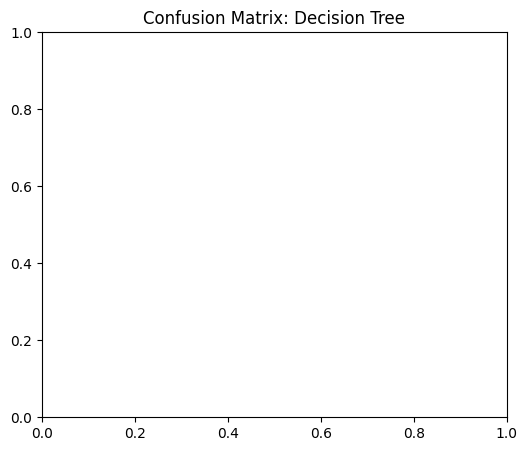

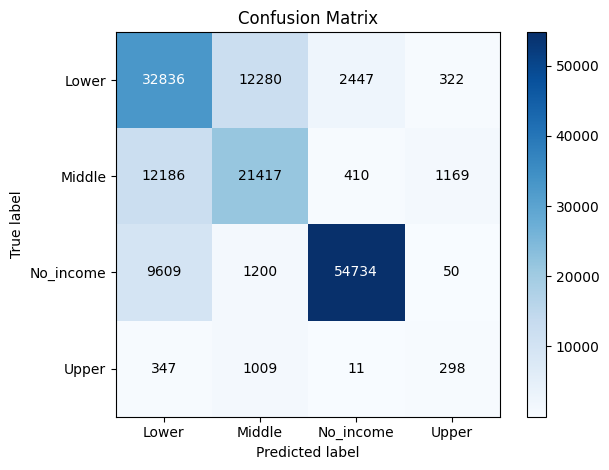

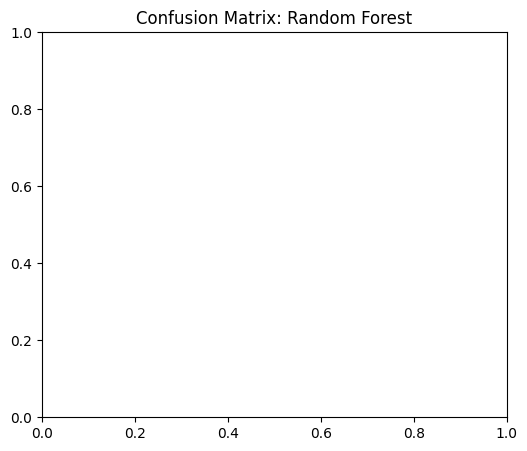

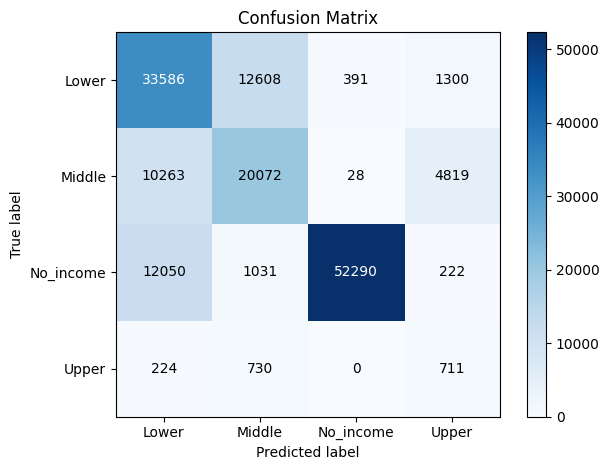

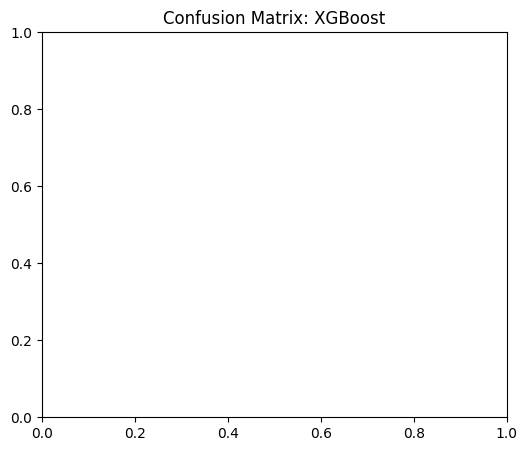

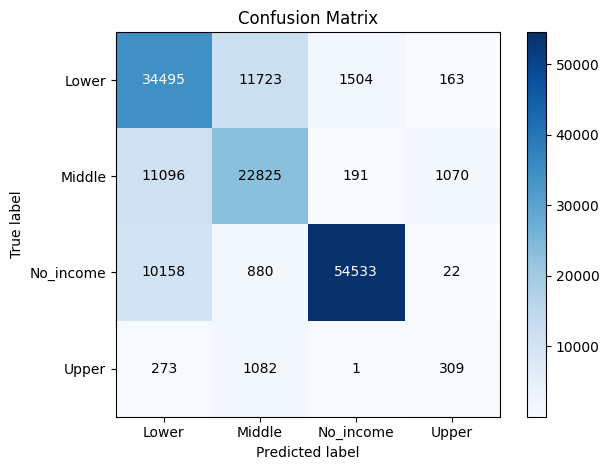

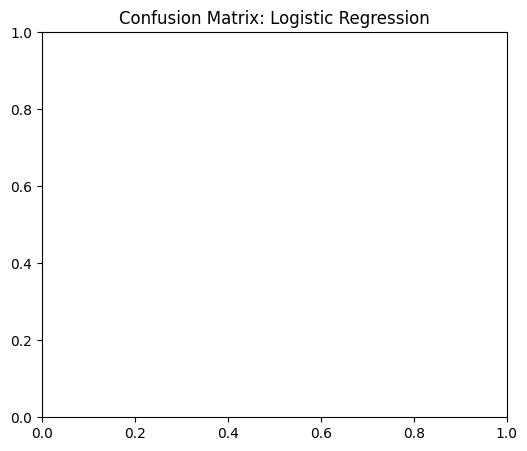

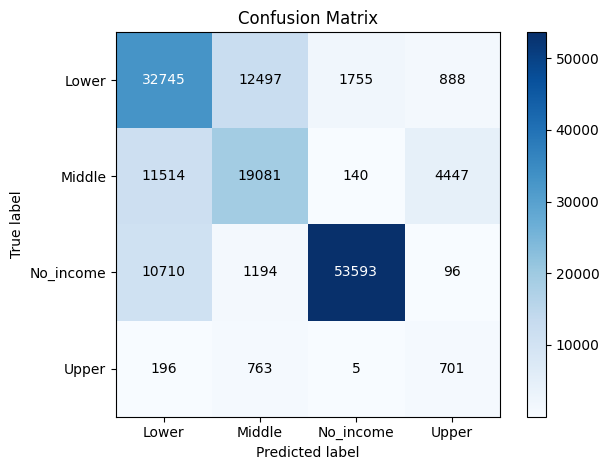

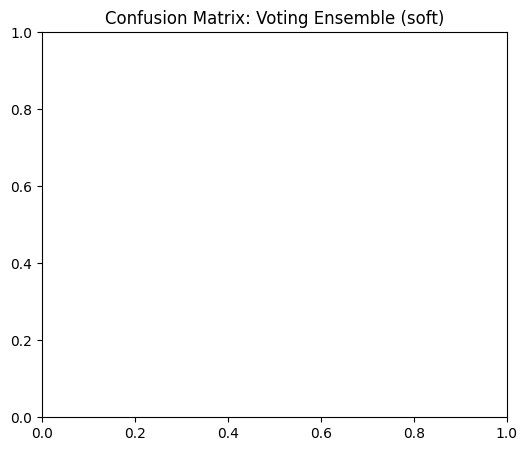

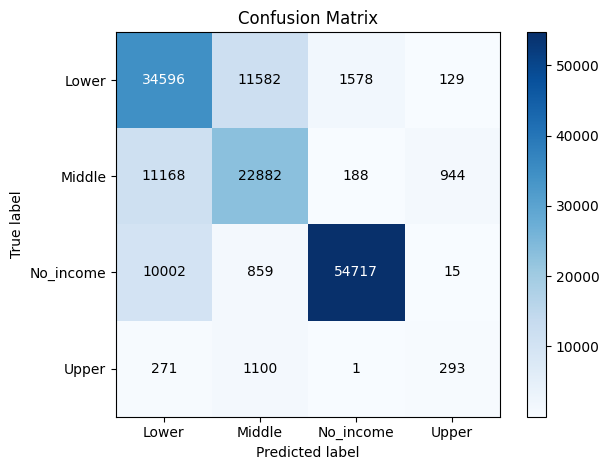

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib
import numpy as np
import scikitplot as skplt
from scikitplot.metrics import plot_confusion_matrix

# Load the label encoder
label_encoder = joblib.load('models/label_encoder.joblib')

# If y_test is integer-encoded, decode it once to string labels
if np.issubdtype(y_test.dtype, np.integer):
    y_test_labels = label_encoder.inverse_transform(y_test)
else:
    y_test_labels = y_test

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred = np.asarray(y_pred).ravel()

    # Decode predictions to string labels too, if they came back as integers
    if np.issubdtype(np.asarray(y_pred).dtype, np.integer):
        y_pred_labels = label_encoder.inverse_transform(y_pred)
    else:
        y_pred_labels = y_pred

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f'Confusion Matrix: {name}')
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.tight_layout()
    plt.savefig(f'results/figures/confusion_matrix_{fname}.png', dpi=200)
    plt.show()
    plt.close()

## 4. ROC curves (one-vs-rest, multi-class)
`scikit-plot` handles multi-class ROC natively via `predict_proba`. Models without `predict_proba` (e.g. hard-voting ensembles) are skipped here.

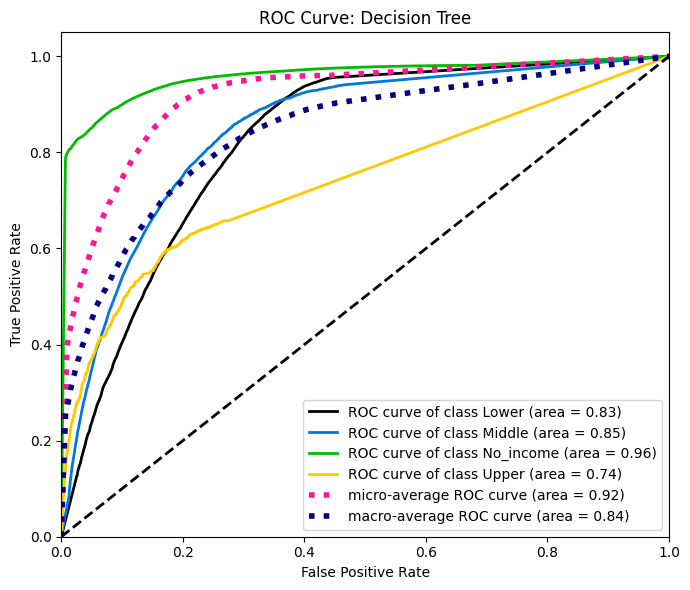

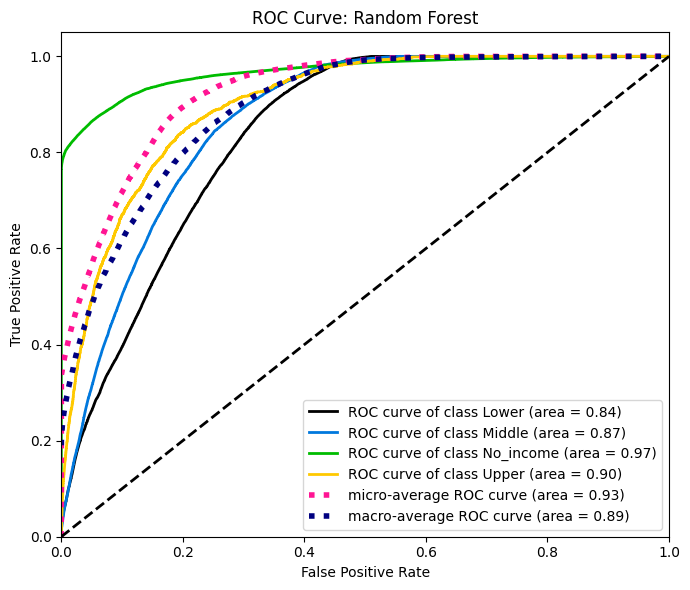

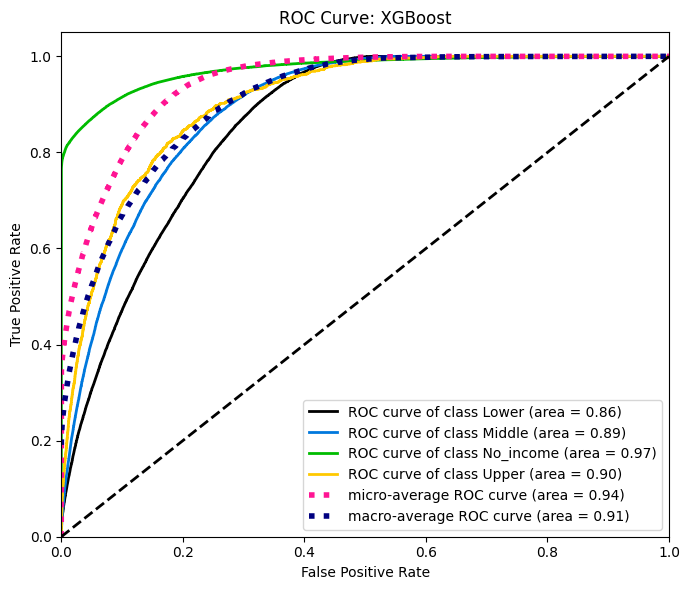

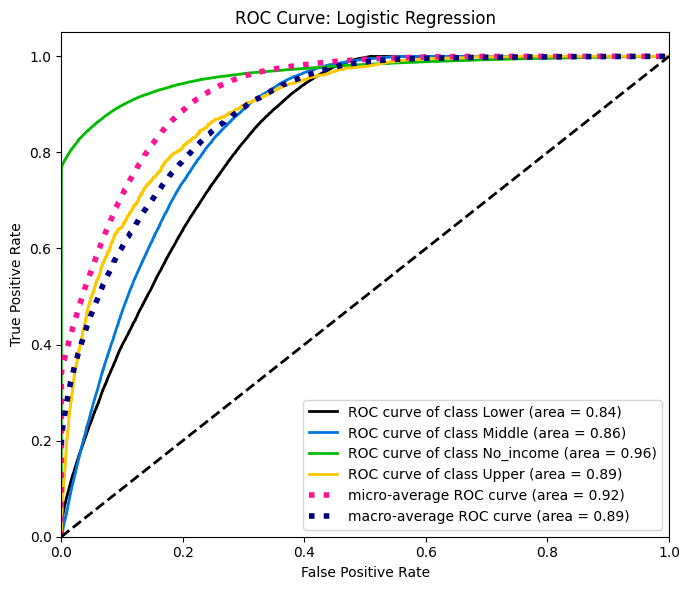

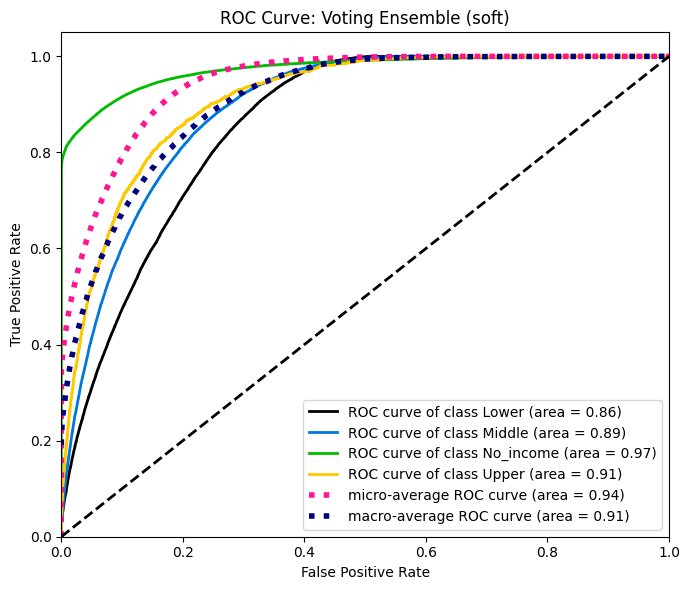

Skipping Voting Ensemble (hard): no predict_proba


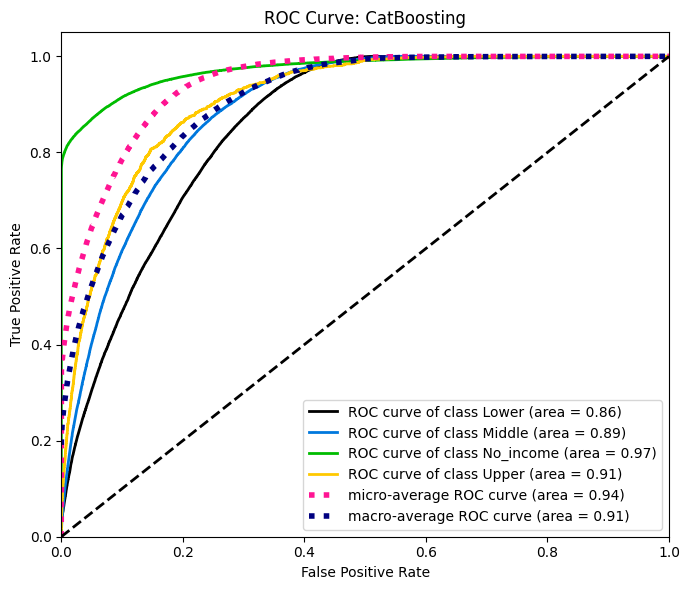

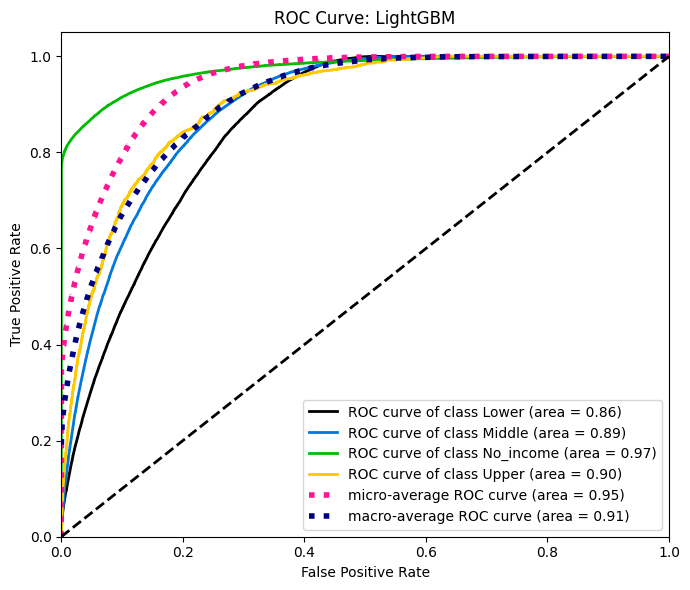

In [32]:
for name, model in models.items():
    if not hasattr(model, 'predict_proba'):
        print(f'Skipping {name}: no predict_proba')
        continue
    y_probas = model.predict_proba(X_test)
    fig, ax = plt.subplots(figsize=(7, 6))
    skplt.metrics.plot_roc(y_test, y_probas, ax=ax)
    ax.set_title(f'ROC Curve: {name}')
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.tight_layout()
    plt.savefig(f'results/figures/roc_curve_{fname}.png', dpi=200)
    plt.show()
    plt.close()

## 5. Precision-Recall curves

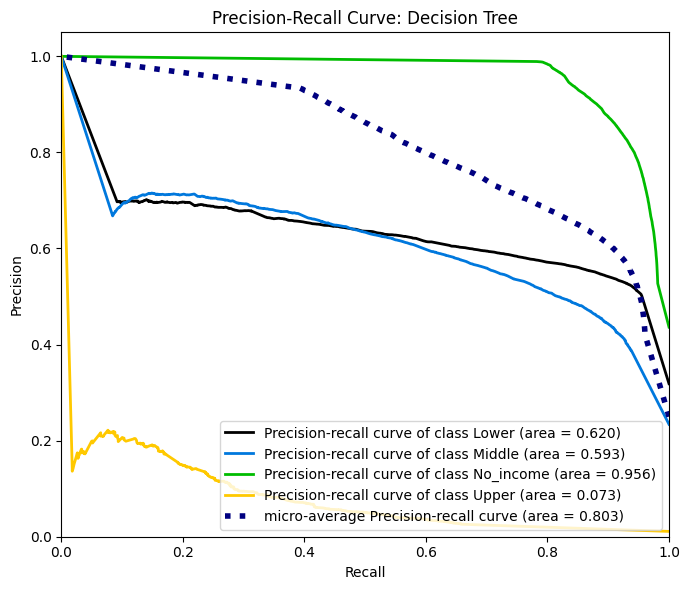

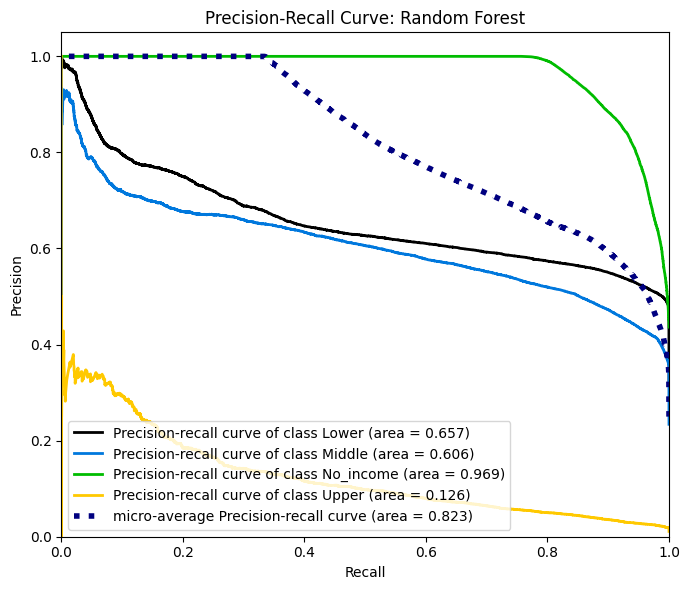

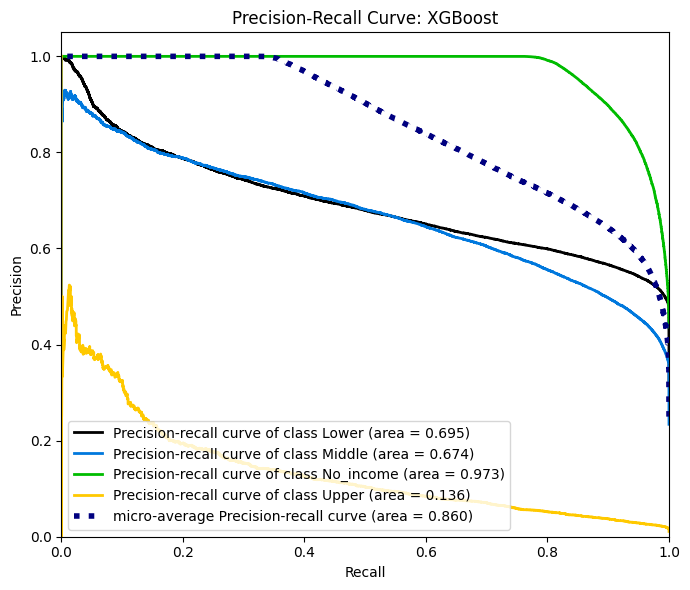

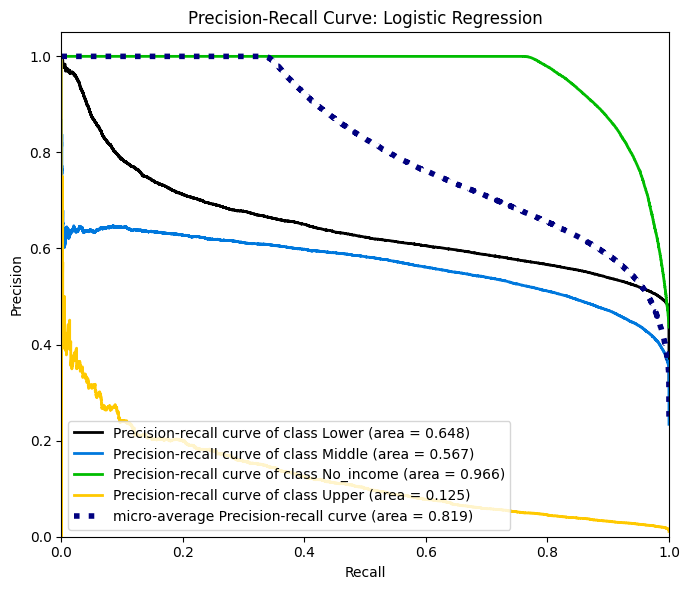

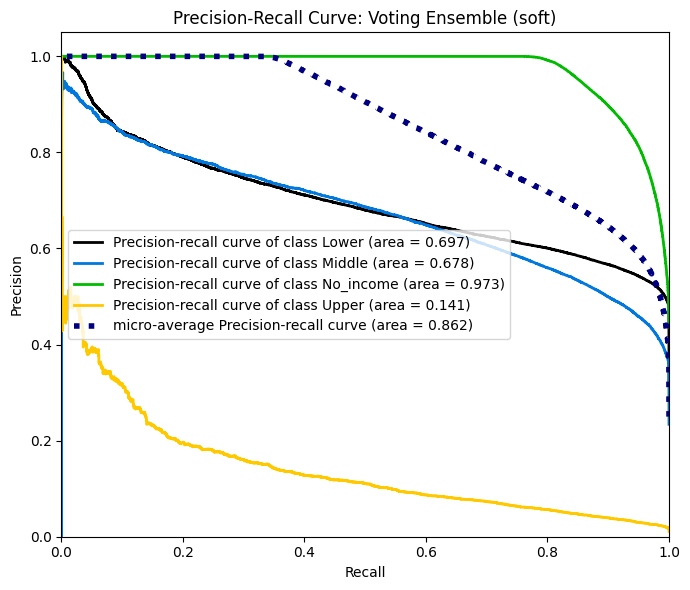

Skipping Voting Ensemble (hard): no predict_proba


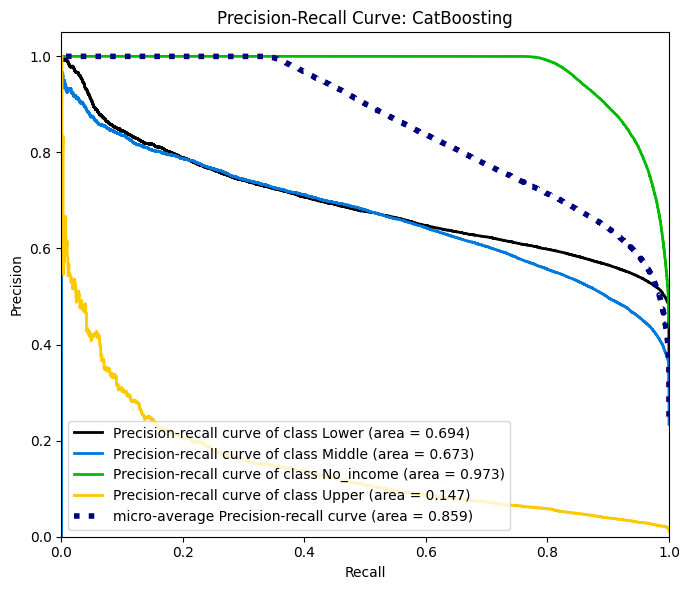

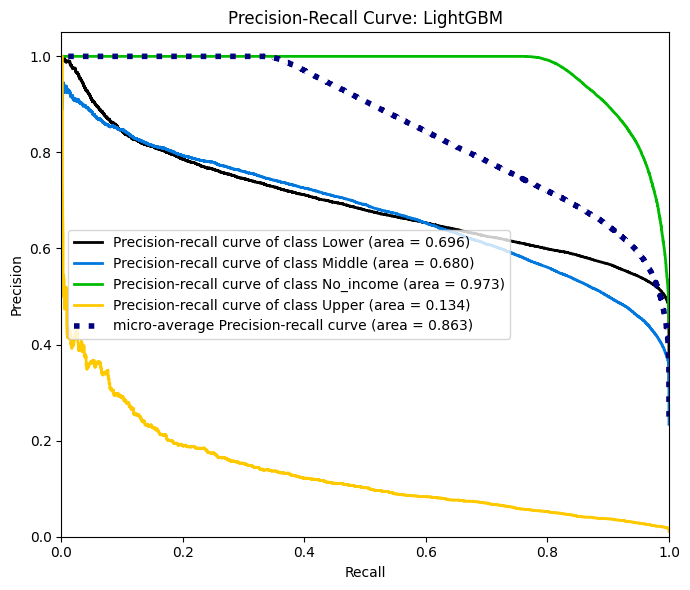

In [33]:
for name, model in models.items():
    if not hasattr(model, 'predict_proba'):
        print(f'Skipping {name}: no predict_proba')
        continue
    y_probas = model.predict_proba(X_test)
    fig, ax = plt.subplots(figsize=(7, 6))
    skplt.metrics.plot_precision_recall(y_test, y_probas, ax=ax)
    ax.set_title(f'Precision-Recall Curve: {name}')
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.tight_layout()
    plt.savefig(f'results/figures/precision_recall_{fname}.png', dpi=200)
    plt.show()
    plt.close()

## 6. Feature importance bar chart (tree-based models only)
Not from scikit-plot, but useful alongside it and cheap to add here since it reads the same loaded models.

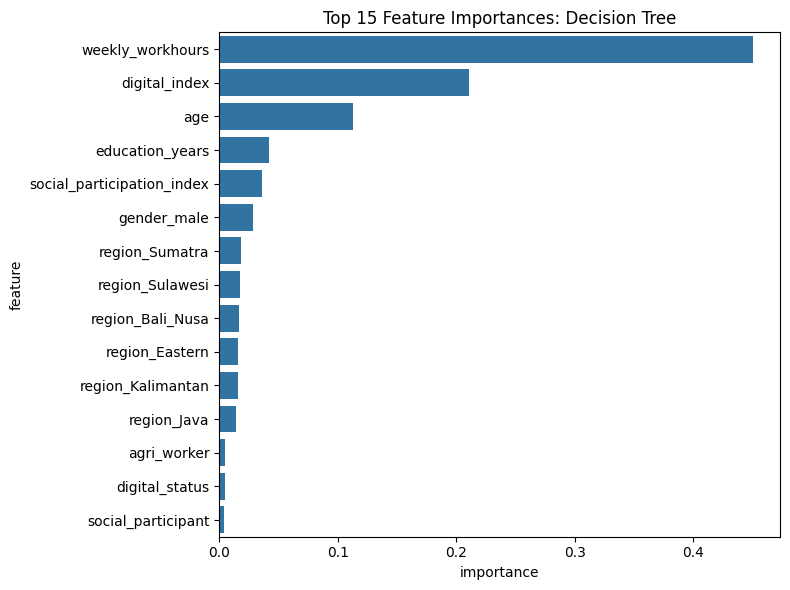

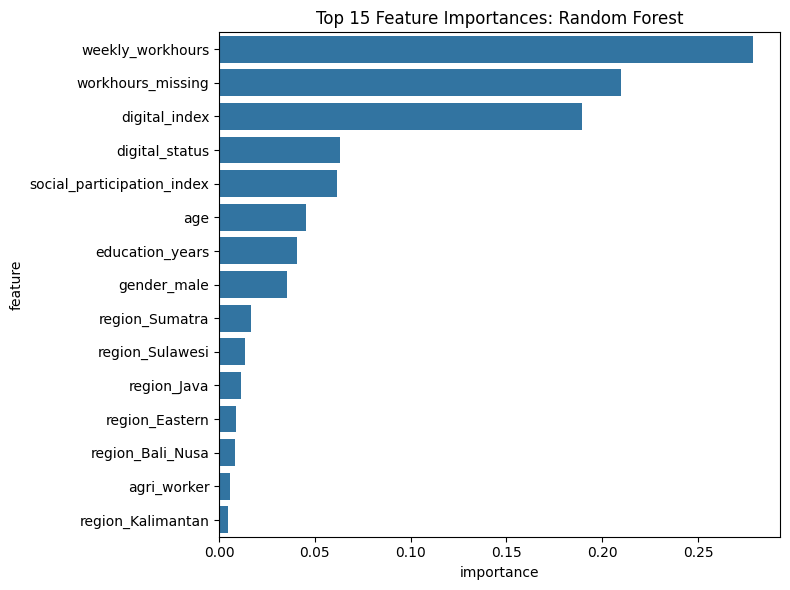

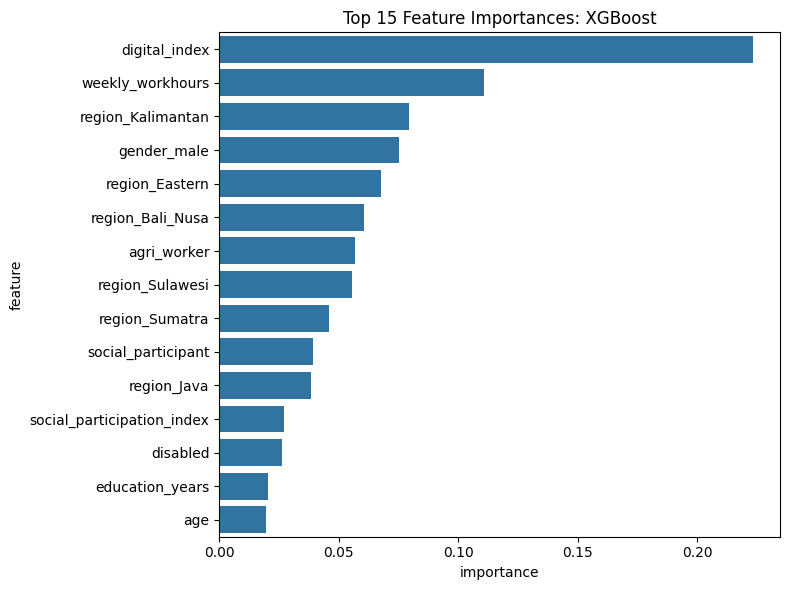

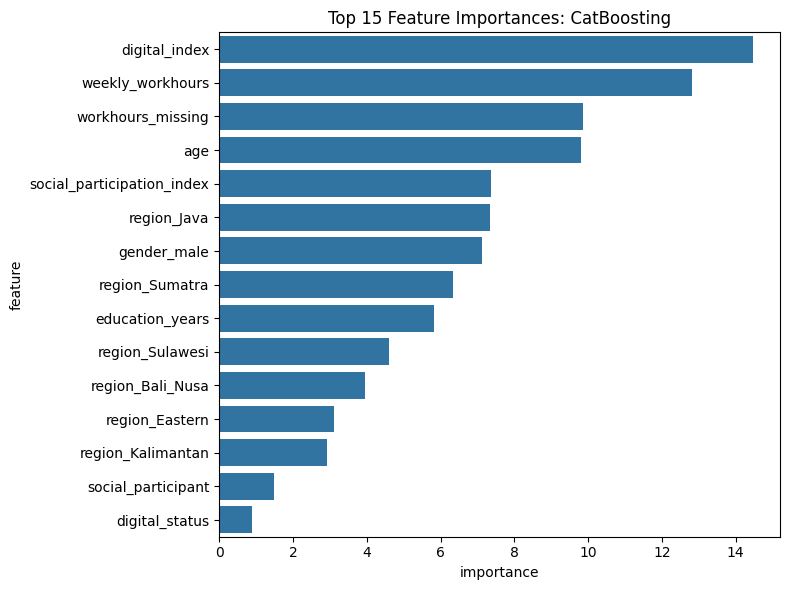

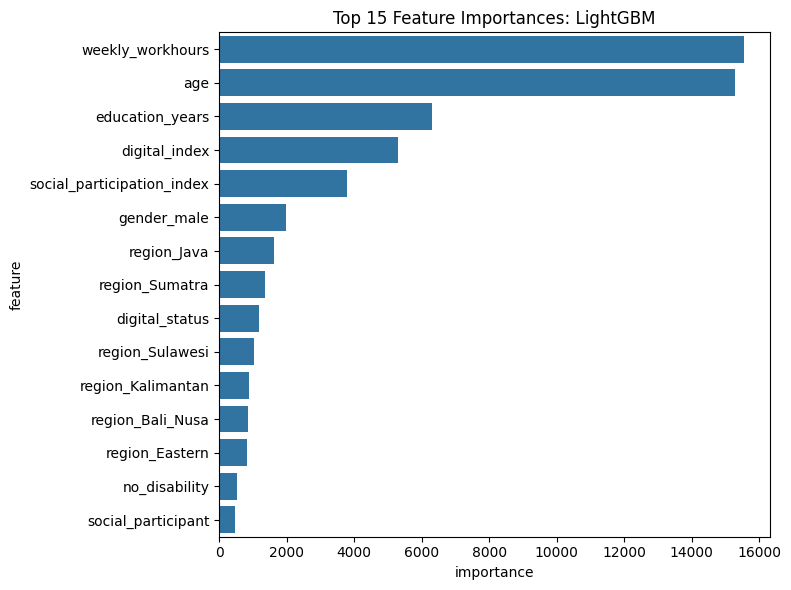

In [35]:
import seaborn as sns

for name in ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoosting','LightGBM']:
    model = models[name]
    importances = model.feature_importances_
    feat_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=feat_df, x='importance', y='feature')
    plt.title(f'Top 15 Feature Importances: {name}')
    plt.tight_layout()
    fname = name.lower().replace(' ', '_')
    plt.savefig(f'results/figures/feature_importance_{fname}.png', dpi=200)
    plt.show()
    plt.close()

## 7. Summary
All figures saved to `results/figures/`. This folder feeds directly into SPR-08c (Report: Experimental Results).

In [3]:
!zip -r results.zip results

  adding: results/ (stored 0%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/confusion_matrix_random_forest.png (deflated 12%)
  adding: results/figures/precision_recall_xgboost.png (deflated 9%)
  adding: results/figures/roc_curve_random_forest.png (deflated 8%)
  adding: results/figures/roc_curve_xgboost.png (deflated 9%)
  adding: results/figures/feature_importance_lightgbm.png (deflated 22%)
  adding: results/figures/precision_recall_catboosting.png (deflated 9%)
  adding: results/figures/roc_curve_decision_tree.png (deflated 8%)
  adding: results/figures/precision_recall_voting_ensemble_soft.png (deflated 8%)
  adding: results/figures/roc_curve_voting_ensemble_soft.png (deflated 8%)
  adding: results/figures/precision_recall_lightgbm.png (deflated 8%)
  adding: results/figures/feature_importance_xgboost.png (deflated 23%)
  adding: results/figures/precision_recall_decision_tree.png (deflated 8%)
  adding: results/figures/roc_curve_catboosting.png (deflated 9%)
 